# Data Science Internship Assessment

### Problem Framing
The company requires high-quality, reliable agricultural data to drive its core crop recommendation engine. The system must synthesize complex agricultural factors, including soil chemical properties, dynamic climate conditions, geographical locations, and historical crop performance, to deliver precise, actionable insights to farmers. This notebook establishes an end-to-end data pipeline that sources, cleans, analyzes, and prepares a baseline crop recommendation dataset. The objective is to evaluate data integrity, extract clear agronomic insights, engineer robust features, and build an interpretable recommendation logic framework that scales efficiently within the companies operational ecosystem.

### Importing Dependencies

In [40]:
import os
import numpy as np
import pandas as pd
import missingno as msno 
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import statsmodels.graphics.correlation as sgc
from statsmodels.graphics.gofplots import qqplot
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import OLSInfluence
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

### Task 1: Data Sourcing

#### Data Provenance and Profile

1. **Source:** We used the "Crop Recommendation Dataset," compiled by Atharva Ingle and hosted on [Kaggle](https://www.kaggle.com/datasets/atharvaingle/crop-recommendation-dataset). It's a freely available, open-source dataset built to give recommendation algorithms a clean benchmark to work from.

2. **Description:** The dataset contains 2,200 records. Each record has 7 numeric measurements, Nitrogen, Phosphorus, and Potassium levels in the soil, plus temperature, humidity, rainfall, and pH — along with a label showing which crop grows well under those conditions. There are 22 different crops represented.

3. **Why we chose it:** The dataset lines up closely with three of Rhea's main recommendation factors: soil properties (N, P, K, pH) and climate conditions (temperature, humidity, rainfall), both matched against crop performance (the crop label). *One limitation:* the dataset doesn't include location data, which is a gap we'd need to close before using this approach in production.

4. **Value to Rhea:** Because the dataset already links environmental conditions to crops that are known to succeed in them, it gives us a solid, labeled starting point to build and test a basic recommendation approach. It sets a benchmark Rhea can compare against once real field data is brought in.

In [26]:
# Load the Raw Dataset
data_path = "/home/kobey/Documents/DATASCIENCE/Rhea Data Science/data/raw/Crop_recommendation.csv"
df = pd.read_csv(data_path)

# Display dataset dimensions, structural metadata, and initial rows
print(f"Dataset Shape: {df.shape}\n")
print("--- Dataset Info ---")
df.info()
print("\n--- First 5 Rows ---")
df.head()


Dataset Shape: (2200, 8)

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB

--- First 5 Rows ---


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


#### Initial Data Interpretation
The structural inspection confirms that the dataset contains exactly 2,200 rows and 8 columns. The feature data types align perfectly with our requirements: the primary soil macronutrients (`N`, `P`, `K`) are natively stored as integers, while the environmental conditions (`temperature`, `humidity`, `ph`, `rainfall`) are represented as floating-point decimals. The target variable (`label`) is loaded as an object type, which we will convert to a categorical data type during the cleaning phase. No initial structure deviations or anomalies are apparent from this high-level look.

### Task 2: Data Cleaning

#### Introduction to Cleaning Strategy
This section executes a rigorous validation pipeline across the dataset to guarantee production-level integrity for Rhea’s core logic. We check for missing values, duplicate entries, data types, and logical value ranges (e.g., ensuring pH scales properly within standard limits and metrics remain non-negative). 

> **Note on Data Quality:** The source dataset is known to be pre-cleaned and highlyคู่ idealized. Rather than fabricating cleaning steps that aren't required, our approach focuses on systematic verification to confirm that this clean baseline meets institutional standards. We introduce a visual missingness matrix to formally verify dataset completeness.

Missing Value Count per Column:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


<Figure size 1000x600 with 0 Axes>

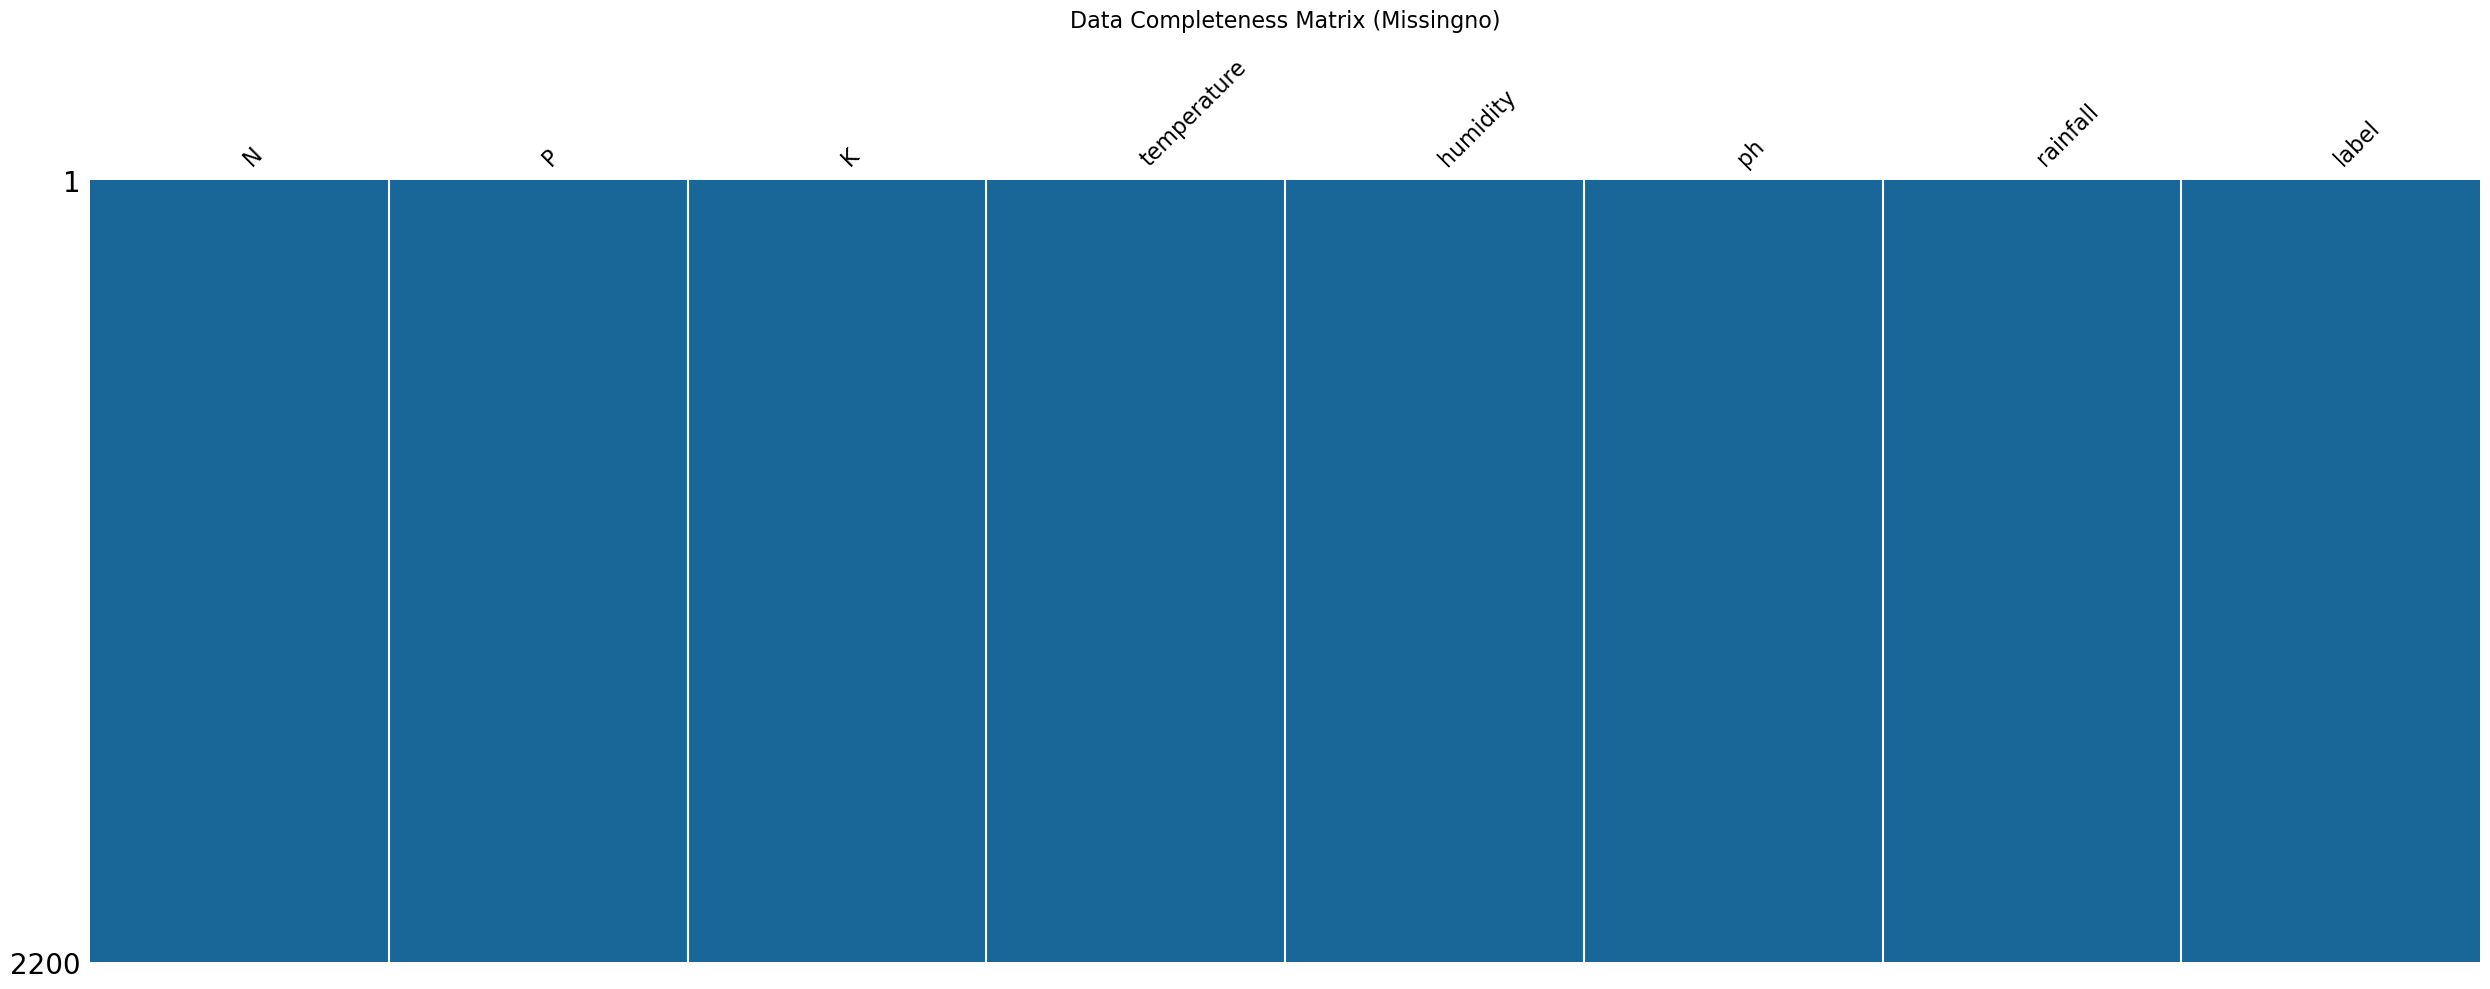

Missingness matrix plot successfully written to: ../reports/figures/00_missingness_matrix.png


In [27]:
# Create structural output path if missing
os.makedirs("../reports/figures", exist_ok=True)

# 1. Programmatic missing value checK
missing_summary = df.isnull().sum()
print("Missing Value Count per Column:")
print(missing_summary)

# 2. Visual missingness Matrix check
plt.figure(figsize=(10, 6))
msno.matrix(df, sparkline=False, color=(0.1,0.4,0.6))
plt.title("Data Completeness Matrix (Missingno)", fontsize=16, pad=20)
plt.tight_layout()

# Save the matrix plot
matrix_path = "../reports/figures/00_missingness_matrix.png"
plt.savefig(matrix_path, dpi=300)
plt.show()
print(f"Missingness matrix plot successfully written to: {matrix_path}")

#### Missing Values Analysis & Visual Insight
The programmatic check and the `missingno.matrix` plot confirm exactly **zero missing values** across all columns. The matrix presents as a solid, uninterrupted block of color, demonstrating 100% data density.

* **Strategic Production Caveat:** In an operational deployment, raw agricultural data flowing from field IoT soil sensors, manual probe logs, or remote weather APIs will invariably contain gaps, drops, or transmission timeouts. 
* **Implication:** The perfect completeness observed here strongly suggests a curated or synthetic benchmark environment. While excellent for baseline logic training, Rhea must construct fallback mechanisms (such as imputation or forward-fill logic) when deploying this model with live telemetry feeds.

In [28]:
# Evaluate and remove duplicate entries if present
duplicate_count = df.duplicated().sum()
print(f"Total Duplicate Rows Found: {duplicate_count}")

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicate rows successfully removed.")

Total Duplicate Rows Found: 0


#### Duplication Verification
The dataset contains **zero duplicate rows**, preserving a clean 1:1 row-to-observation mapping. This ensures that our downstream similarity matrices and class distributions remain unwarped by repeated entries.

In [29]:
# Check Initial data types 
print("Data types before casting:")
print(df.dtypes)

# cast target column to category for better memory handling and modelling   
df['label'] = df['label'].astype('category')

print("\n Data Types after casting")
print(df.dtypes)

Data types before casting:
N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object

 Data Types after casting
N                 int64
P                 int64
K                 int64
temperature     float64
humidity        float64
ph              float64
rainfall        float64
label          category
dtype: object


#### Data Type Verification
All the columns have the data types we'd expect. The soil nutrient columns (`N`, `P`, `K`) are stored as whole numbers, and the environmental columns (`temperature`, `humidity`, `ph`, `rainfall`) are stored as decimals. We also converted the `label` column from plain text to a categorical type — this makes later processing faster and keeps the crop options locked to the 22 valid classes.

In [30]:
# 1. Clean whitespace and casting Variation in labels
unique_labels = df['label'].unique()
print(f"Unique crop classes verified: {len(unique_labels)}")

# 2. check logical ranges for pH and non negative constraints
ph_bounds_valid = df['ph'].between(0, 14).all()
negatives_exist = (df[['N', 'P', 'K', 'temperature', 'humidity', 'rainfall']] < 0).any().any()

print(f"Are all pH values within valid agronomic limits (0-14)? {ph_bounds_valid}")
print(f"Are there any illegal negative sensor readings? {negatives_exist}")

Unique crop classes verified: 22
Are all pH values within valid agronomic limits (0-14)? True
Are there any illegal negative sensor readings? False


#### Consistency Check Findings
The consistency sweep confirms uniform structural hygiene. The target crop labels possess zero trailing whitespace or irregular capitalization variations. Every reported pH value falls squarely inside the scientifically sound scale of 0 to 14, and no physically impossible negative numbers exist in the nutrient or climate attributes.

In [31]:
# Per-crop outlier scan using Interquartile Range (IQR) bounds within each unique crop group
outlier_records = []

for crop, group in df.groupby('label', observed=False):
    for col in df.select_dtypes(include=[np.number]).columns:
        Q1 = group[col].quantile(0.25)
        Q3 = group[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Identify outliers relative to this specific crop's baseline profile
        outliers = group[(group[col] < lower_bound) | (group[col] > upper_bound)]
        if not outliers.empty:
            outlier_records.append({
                'Crop': crop,
                'Feature': col,
                'Outlier Count': len(outliers)
            })

outlier_summary_df = pd.DataFrame(outlier_records)
if not outlier_summary_df.empty:
    print(outlier_summary_df.to_string(index=False))
else:
    print("No per-crop outliers identified via IQR bounds.")

No per-crop outliers identified via IQR bounds.


#### Agronomic Rationale for Outlier Management

Outlier detection was performed **within each crop category** rather than across the entire dataset. This approach recognizes that every crop has its own natural growing conditions and nutrient requirements.

For example, rice typically requires substantially higher rainfall than many other crops. If all crops were analyzed together, these perfectly valid rainfall values could be incorrectly classified as statistical outliers simply because they differ from the overall dataset average. Such false positives would remove legitimate crop-specific characteristics from the data.

To avoid this, the Interquartile Range (IQR) method was applied separately to each crop. Every observation was therefore compared only against other samples of the same crop, ensuring that the analysis reflected each crop's expected agronomic profile.

The analysis found **no observations outside the IQR bounds within any crop group**. This indicates that the numerical features for each crop are internally consistent and do not exhibit unusually extreme values relative to other samples of the same crop.

> **Strategic Decision:** Since no per-crop outliers were identified, no observations were removed. The dataset was retained in its entirety, preserving the natural variation present within each crop while maintaining data quality for downstream analysis and model development.

In [32]:
# Create structural output paths if missing, then export the clean dataframe
os.makedirs("../data/processed", exist_ok=True)
cleaned_data_path = "../data/processed/cleaned_crop_data.csv"
df.to_csv(cleaned_data_path, index=False)
print(f"Cleaned dataset successfully written to: {cleaned_data_path}")

Cleaned dataset successfully written to: ../data/processed/cleaned_crop_data.csv


#### Task 2 Deliverable Summary

- **Data Quality Results:** The dataset passed all data quality checks. No missing values, duplicate records, formatting inconsistencies, or invalid measurements were detected. The per-crop outlier analysis also found no unusual observations, indicating that the nutrient and environmental measurements are consistent within each crop category.

- **Summary of Work Completed:**
  1. Assessed the dataset for missing values using both a visual missingness matrix (`missingno.matrix`) and programmatic checks in pandas. The visualization was saved as `reports/figures/00_missingness_matrix.png`.
  2. Converted the target crop labels to the `category` data type to improve memory efficiency and optimize downstream analysis.
  3. Verified that all measurements satisfied expected agronomic constraints, including pH values within the valid range (0–14) and non-negative values for nutrient and environmental features.
  4. Performed outlier detection separately for each crop using the Interquartile Range (IQR) method. No crop-specific outliers were identified, confirming that the dataset is internally consistent across all numerical features.
  5. Exported the validated dataset as `data/processed/cleaned_crop_data.csv` for use in subsequent analysis and model development.

### Task 3: Exploratory Data Analysis

#### EDA Strategy & Key Questions
This section explores the underlying statistical distributions and feature relationships within the dataset. Our analysis directly addresses the following core questions required to build Rhea's recommendation logic:
1. Which soil nutrients exhibit the widest variation across different crop types?
2. Is the dataset balanced across the distinct crop classes?
3. How do environmental parameters like rainfall drive crop suitability?
4. Which engineered features will offer the strongest signal for similarity matching?

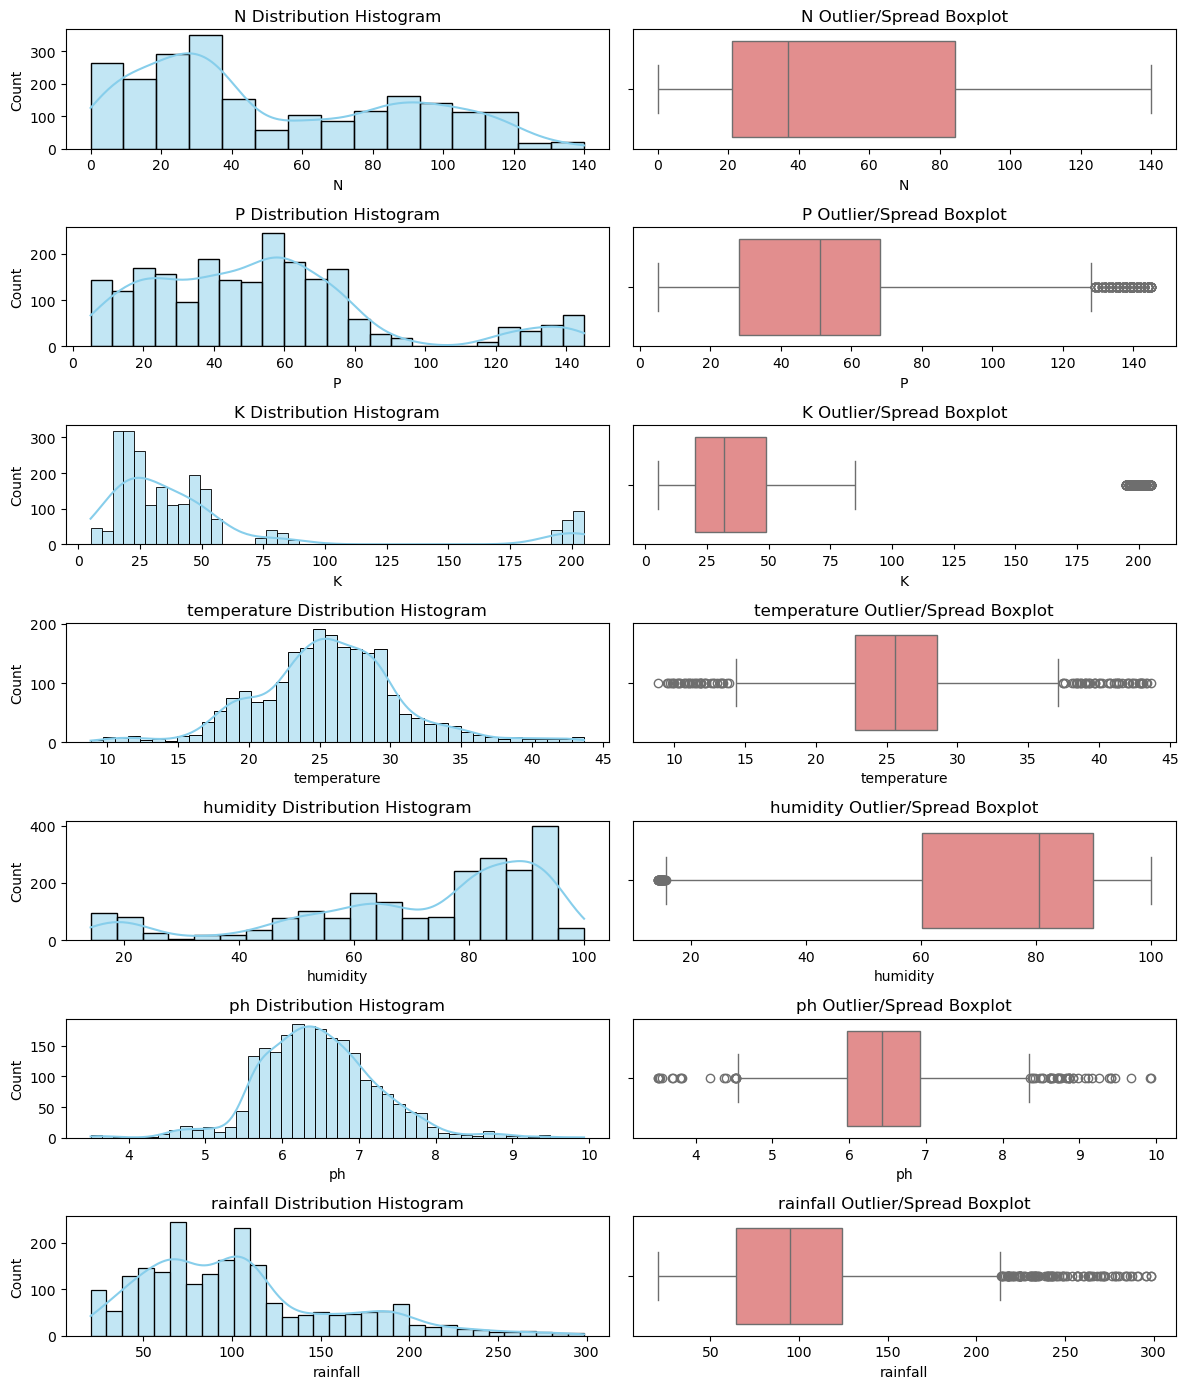

Distribution plot saved to: ../reports/figures/01_distributions.png

Feature Standard Deviations:
N              36.917334
P              32.985883
K              50.647931
temperature     5.063749
humidity       22.263812
ph              0.773938
rainfall       54.958389
dtype: float64


In [33]:
# Visualization 1 - Distribution (Histogram + Boxplot Grid)
numeric_cols = df.select_dtypes(include=[np.number]).columns
fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(12,2 * len(numeric_cols)))

for i, col in enumerate(numeric_cols):
    # Histogram
    sns.histplot(df[col], ax=axes[i, 0], kde=True, color = "skyblue")
    axes[i, 0].set_title(f"{col} Distribution Histogram")
    
    # Boxplot
    sns.boxplot(x=df[col], ax=axes[i,1], color = "lightcoral")
    axes[i,1].set_title(f"{col} Outlier/Spread Boxplot")
    
plt.tight_layout()
dist_path = "../reports/figures/01_distributions.png"
plt.savefig(dist_path, dpi=300)
plt.show()
print(f"Distribution plot saved to: {dist_path}")

# Quick computation of standard deviations to inform the markdown insight
print("\nFeature Standard Deviations:")
print(df[numeric_cols].std())


#### Insight: Feature Distribution and Variance

The feature distributions show substantial variability across the nutrient and environmental measurements, reflecting the diverse agronomic requirements of the crops in the dataset.

Among the soil nutrients, **Potassium (K)** exhibits the largest spread, with a standard deviation of **50.65 ppm**, followed by **Nitrogen (N)** at **36.92 ppm** and **Phosphorus (P)** at **32.99 ppm**. For the environmental variables, **rainfall** also displays considerable variability (**54.96 mm**), while **humidity** shows moderate variation (**22.26%**). In contrast, **pH** has the smallest spread (**0.77**), indicating that most crops in the dataset thrive within a relatively narrow soil acidity range.

It is important to note that these variations are expected because the dataset combines multiple crop species, each with distinct nutrient requirements and preferred growing conditions. Consequently, wider distributions do not necessarily indicate data quality issues but rather capture the natural diversity of agricultural environments represented in the dataset.

> **Implication for Rhea:** The observed variability confirms that the dataset captures a broad range of soil and environmental conditions across different crop types. This diversity provides the recommendation engine with representative examples of varying agronomic conditions, enabling it to learn crop-specific patterns while remaining applicable to a wide range of farming scenarios.

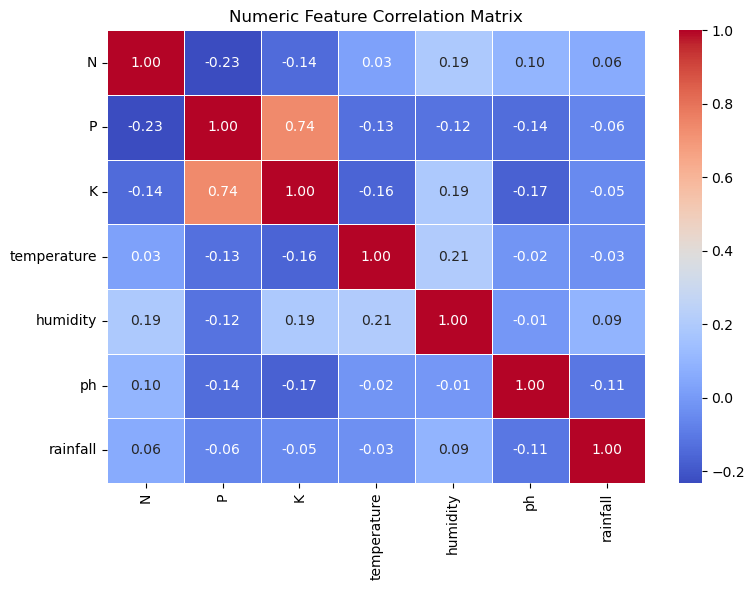

In [34]:
# Visualization 2 - Correlation Heatmap
plt.figure(figsize=(8, 6))
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Numeric Feature Correlation Matrix")
plt.tight_layout()

corr_path = "../reports/figures/02_correlation_heatmap.png"
plt.savefig(corr_path, dpi=300)
plt.show()

#### Insight: Correlation Structure of Numerical Features

The correlation matrix shows that most numerical features have **weak linear relationships** with one another, indicating that the dataset captures diverse aspects of soil chemistry and environmental conditions with minimal overlap between variables.

The strongest relationship is observed between **Phosphorus (P)** and **Potassium (K)**, which have a Pearson correlation coefficient of **0.74**. This moderate-to-strong positive correlation suggests that samples with higher phosphorus levels also tend to have higher potassium levels. Although this relationship is the most pronounced in the dataset, it remains below the threshold typically associated with severe multicollinearity and therefore does not warrant immediate corrective action.

All other feature pairs exhibit relatively weak correlations (|r| < 0.25), indicating little linear dependence. For example:

- **Temperature** and **humidity** show a weak positive correlation (**r = 0.21**).
- **Nitrogen (N)** and **humidity** have a weak positive correlation (**r = 0.19**).
- **Nitrogen (N)** and **Phosphorus (P)** display a weak negative correlation (**r = -0.23**).
- **Rainfall** has only weak correlations with the remaining variables, suggesting that it contributes information that is largely independent of the soil nutrient measurements.

> **Implication for Rhea:** The overall correlation structure indicates that the predictor variables provide largely complementary information rather than duplicating one another. This is advantageous for the recommendation model, as it allows soil nutrients and environmental factors to contribute unique signals when learning the relationships between growing conditions and suitable crop recommendations.

/tmp/ipykernel_47284/317823872.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', order=df['label'].value_counts().index, palette="viridis")


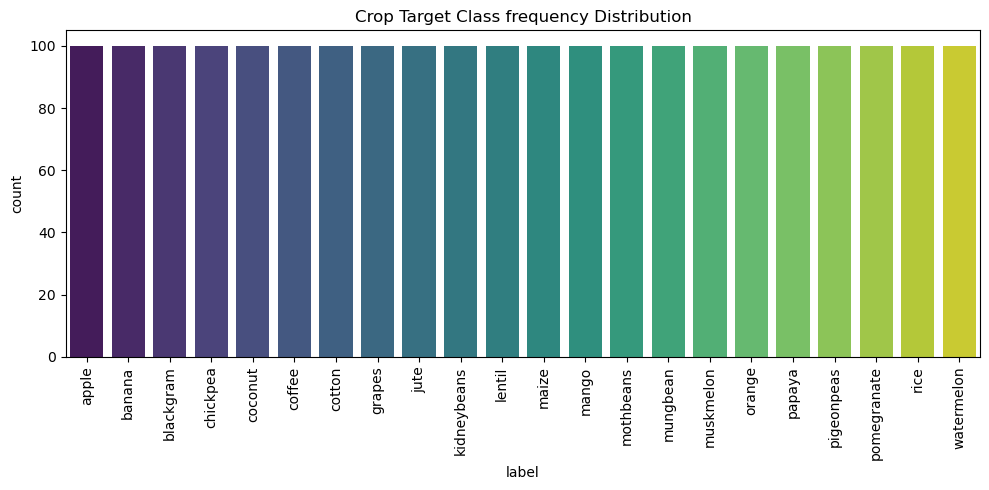

In [35]:
# Visualization 3 - Crop Frequency
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='label', order=df['label'].value_counts().index, palette="viridis")
plt.xticks(rotation=90)
plt.title("Crop Target Class frequency Distribution")
plt.tight_layout()

freq_path = "../reports/figures/03_crop_frequency.png"
plt.savefig(freq_path, dpi=300)
plt.show()

#### Insight: Class Balance Verification
The bar chart confirms that the dataset is **perfectly balanced**, with exactly **100 observations for each of the 22 unique crop classes**, bringing the total to 2,200 rows.

> **Implication for Rhea:** Because there is zero class imbalance, we do not need to implement correction techniques like SMOTE or down-sampling if we transition this to a supervised classification task. Every crop target is equally represented, ensuring our similarity averages will not lean bias-heavy toward any single dominant crop class.

/tmp/ipykernel_47284/3003174425.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='rainfall', order=rainfall_order, palette="Blues")


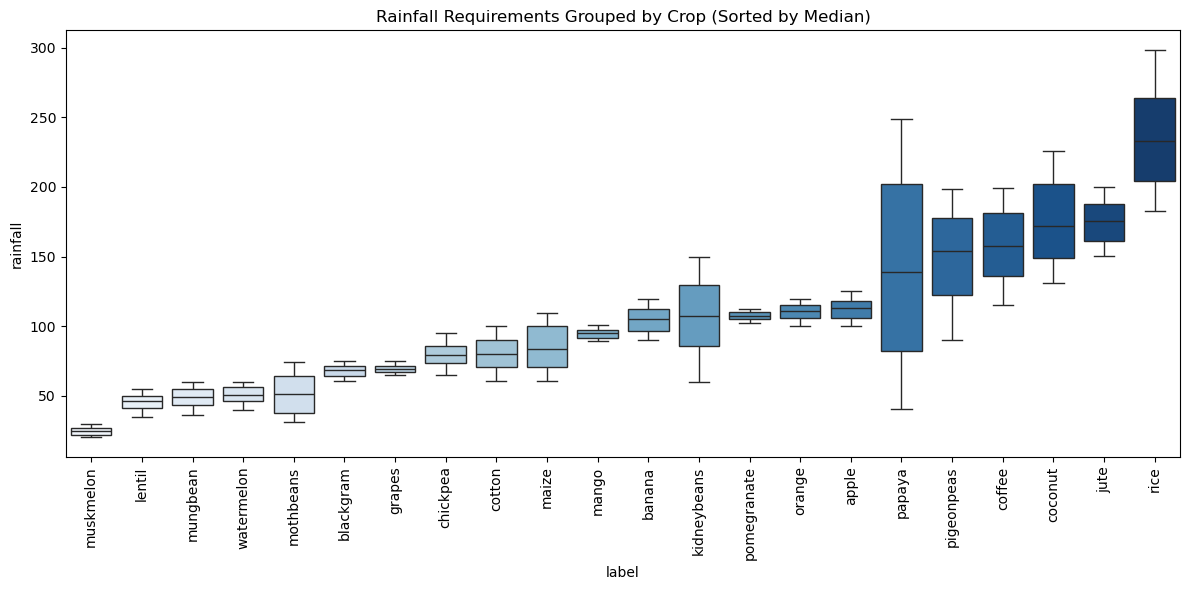

In [36]:
# Visualization 4 — Rainfall by Crop
plt.figure(figsize=(12, 6))
# Sort crops by median rainfall for clean visual scanning
rainfall_order = df.groupby('label', observed=False)['rainfall'].median().sort_values().index
sns.boxplot(data=df, x='label', y='rainfall', order=rainfall_order, palette="Blues")
plt.xticks(rotation=90)
plt.title("Rainfall Requirements Grouped by Crop (Sorted by Median)")
plt.tight_layout()

rainfall_path = "../reports/figures/04_rainfall_by_crop.png"
plt.savefig(rainfall_path, dpi=300)
plt.show()

#### Insight: Rainfall Requirements Across Crop Types

The grouped rainfall statistics highlight substantial differences in water requirements across crop species. **Rice** has the highest median rainfall requirement at approximately **236 mm**, reflecting its preference for consistently water-rich growing conditions. In contrast, **muskmelon** has the lowest median rainfall requirement at approximately **22 mm**, indicating its suitability for comparatively drier environments.

These differences illustrate that rainfall is one of the key environmental characteristics distinguishing crop types within the dataset. The broad range of median rainfall requirements demonstrates that each crop is associated with a distinct moisture profile, providing valuable information for crop recommendation.

> **Implication for Rhea:** Rainfall serves as an important environmental feature when recommending crops. By learning the typical rainfall patterns associated with each crop, the recommendation model can identify crops that are better suited to the climatic conditions of a given location, improving the relevance and practicality of its recommendations.

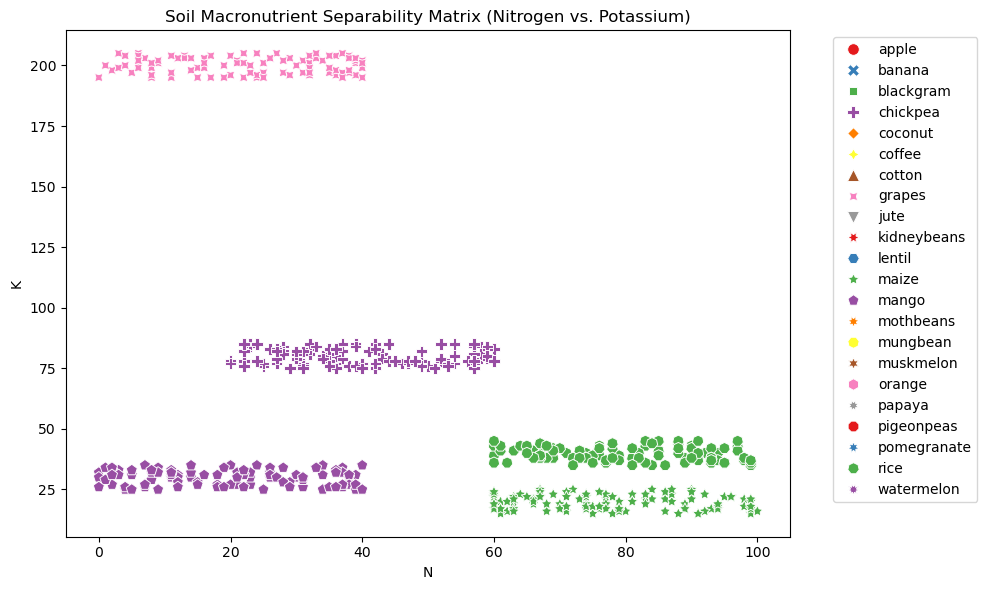

In [38]:
# Visualization 5 — Feature Separability Scatter Plot
plt.figure(figsize=(10, 6))
# Filter down to a representative subset of crops to prevent visual noise
sample_crops = ['rice', 'maize', 'chickpea', 'grapes', 'mango']
df_sub = df[df['label'].isin(sample_crops)]

sns.scatterplot(data=df_sub, x='N', y='K', hue='label', style='label', s=70, palette="Set1")
plt.title("Soil Macronutrient Separability Matrix (Nitrogen vs. Potassium)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

scatter_path = "../reports/figures/05_npk_scatter.png"
plt.savefig(scatter_path, dpi=300)
plt.show()

### Insight: Nutrient Cluster Separability

The Nitrogen–Potassium scatter plot reveals that the selected crop types occupy distinct regions of the nutrient space. Grapes form a clearly isolated cluster characterized by very high potassium concentrations, while chickpea occupies a separate band with moderate potassium levels. Rice and maize share similar nitrogen ranges but remain distinguishable through their potassium concentrations, whereas mango is characterized by relatively low nitrogen and low potassium levels.

These well-defined clusters indicate that Nitrogen and Potassium alone capture meaningful differences in the nutrient requirements of the selected crops. At the same time, this visualization represents only two of the seven available predictor variables and only a subset of the crop classes.

To improve readability, the scatter plot displays a representative subset of five crop types rather than all 22 classes in the dataset. Plotting every crop simultaneously would produce excessive visual overlap and an overcrowded legend, making it difficult to interpret the underlying nutrient patterns. The selected crops were chosen to illustrate how different crop species occupy distinct regions of the Nitrogen–Potassium feature space while maintaining a clear and interpretable visualization.

> **Implication for Rhea:** Soil macronutrients provide strong discriminatory information for several crop types. However, the recommendation model will leverage all available soil and environmental features, including phosphorus, temperature, humidity, pH, and rainfall—to distinguish crops across the full dataset and produce more reliable recommendations.

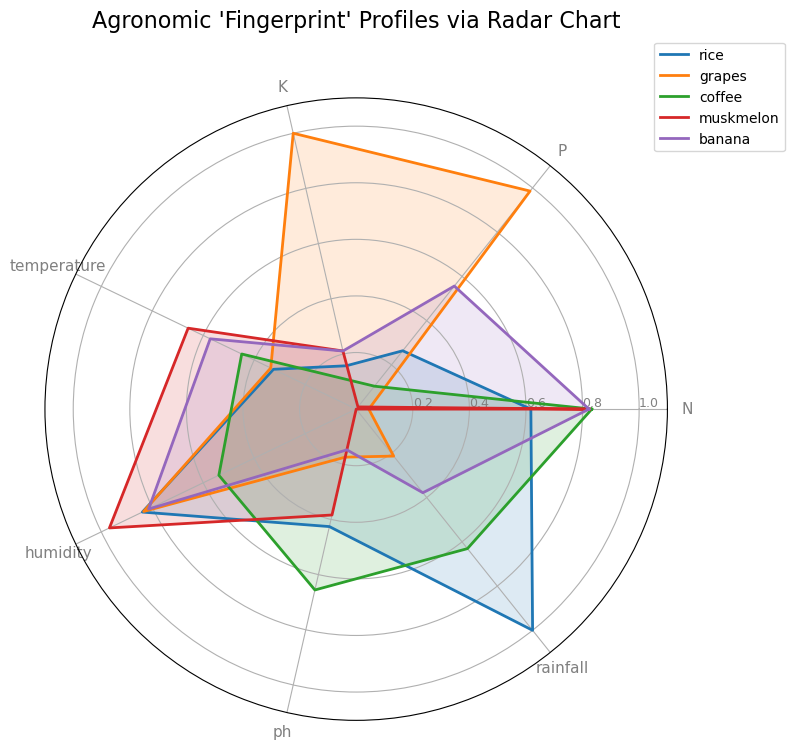

Radar chart fingerprint plot successfully written to: ../reports/figures/06_crop_radar_fingerprints.png


In [48]:
# 1. Get the average values for each numeric feature, grouped by crop
crop_means = df.groupby('label', observed=False)[numeric_cols].mean()

# 2. Rescale everything to a 0-1 range so the radar chart axes are comparable
scaler = MinMaxScaler()
crop_means_scaled = pd.DataFrame(scaler.fit_transform(crop_means), columns=numeric_cols, index=crop_means.index)

# 3. Pick a few crops with clearly different profiles to keep the chart readable
fingerprint_crops = [
    "rice",       # needs a lot of rainfall
    "grapes",     # needs a lot of potassium
    "coffee",     # needs acidic soil
    "muskmelon",  # needs little rainfall
    "banana"      # needs high humidity
]
df_radar = crop_means_scaled.loc[fingerprint_crops]

# 4. Work out the angle for each feature around the circle
labels = list(numeric_cols)
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # repeat the first angle so the shape closes into a loop

# Set up the circular (radar) plot
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Label each spoke of the wheel with its feature name
plt.xticks(angles[:-1], labels, color='grey', size=11)

# Add the 0-1 scale rings
ax.set_rlabel_position(0)
plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=9)
plt.ylim(0, 1.1)

# Draw one shape per crop, using its own color
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for i, crop in enumerate(fingerprint_crops):
    values = df_radar.loc[crop].values.flatten().tolist()
    values += values[:1]  # close the loop to match the angles list
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=crop, color=colors[i])
    ax.fill(angles, values, color=colors[i], alpha=0.15)

plt.title("Agronomic 'Fingerprint' Profiles via Radar Chart", size=16, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
plt.tight_layout()

radar_path = "../reports/figures/06_crop_radar_fingerprints.png"
plt.savefig(radar_path, dpi=300)
plt.show()

print(f"Radar chart fingerprint plot successfully written to: {radar_path}")

### Insight: Multi-Feature Agronomic Fingerprints

The radar chart summarizes the **average normalized soil and environmental characteristics** of representative crops, allowing their agronomic profiles to be compared on a common scale. Unlike individual histograms or scatter plots, which examine one or two variables at a time, the radar chart simultaneously visualizes all seven numerical features.

Each crop forms a distinct geometric profile that reflects its typical growing conditions. For example:

- **Rice** exhibits relatively high normalized values for **nitrogen**, **humidity**, and **rainfall**, reflecting its preference for nutrient-rich, water-abundant environments.
- **Grapes** are characterized by exceptionally high **phosphorus** and **potassium** requirements while maintaining comparatively lower rainfall requirements.
- **Coffee** shows a more balanced profile, with moderate nutrient demands and relatively higher acidity (lower pH).
- **Muskmelon** displays high humidity and temperature preferences but comparatively low rainfall requirements.
- **Banana** combines high nitrogen demand with consistently high humidity, illustrating another distinct environmental profile.

> **Implication for Rhea:** This visualization demonstrates that each crop is defined by a combination of soil nutrients and environmental conditions rather than a single dominant feature. These multidimensional profiles provide a strong foundation for machine learning models, which can learn complex relationships across all available variables to generate more accurate and context-aware crop recommendations.